In [178]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# append my path
project_root = os.path.abspath('..')
sys.path.append(project_root)

from utils.utils import *

In [179]:
data = load_saved_data("data_with_spikes_and_speed")

In [ ]:
def get_spike_count_data(
    data, 
    session="B", 
    stimulus="natural_scenes"
):
    """Return long-form spike counts with explicit trial and cell ids."""
    session_data = data["sessions"][session]
    spikes = np.asarray(session_data["spikes"], dtype=float)
    stim_table = session_data["stim_tables"][stimulus]

    rows = []
    for trial_idx, trial in stim_table.iterrows():
        start_idx = int(trial["start"])
        stop_idx = int(trial["end"])

        spike_count = spikes[:, start_idx:stop_idx].mean(axis=1)
        rows.extend(
            {
            "trial": int(trial_idx), 
            "cell": int(cell_idx), 
            "spike_count": float(spike_count[cell_idx])
            }
            for cell_idx in range(spike_count.shape[0])
        )

    return pd.DataFrame(rows)

In [158]:
def fit_van_mises(
    data,
    spike_counts_df,
    session="B",
    stimulus="drifting_gratings",
    parameter="orientation",
):
    """Fit a von Mises curve per cell using aligned (count, stimulus) pairs."""
    session_data = data["sessions"][session]
    stim_table = session_data["stim_tables"][stimulus].copy()
    stim_table["trial"] = stim_table.index.astype(int)

    merged = spike_counts_df.merge(
        stim_table[["trial", parameter]], on="trial", how="left"
    )

    fitted_params = []
    for cell_idx, df_cell in merged.groupby("cell", sort=True):
        counts = df_cell["spike_count"].to_numpy(dtype=float)
        stim = df_cell[parameter].to_numpy(dtype=float)

        # Filter out any NaN or infinite values
        valid = np.isfinite(counts) & np.isfinite(stim)
        counts = counts[valid] # shape (n_valid_trials,)
        stim = stim[valid] # shape (n_valid_trials,)

        params = tuningCurve(counts, stim)
        fitted_params.append(
            {
                "cell": int(cell_idx),
                "stimulus_parameters": stim,
                "spike_counts": counts,
                "van-mises-params": params,
            }
        )

    return fitted_params

In [159]:
def compute_tuning_significance(fitted_params, psi=2, niters=1000, random_seed=2046):
    """Permutation-based tuning significance per cell.
    """
    p_values = {}
    for entry in fitted_params:
        cell = int(entry["cell"])
        stim = np.asarray(entry["stimulus_parameters"], dtype=float)
        counts = np.asarray(entry["spike_counts"], dtype=float)

        p_value, q_abs, _ = testTuning(
            counts, stim, psi=psi, niters=niters, random_seed=random_seed
        )
        p_values[cell] = p_value

    return p_values

In [ ]:
def plot_tuning_curves(
    fitted_params,
    p_values=None,
    n_cols=4,
    alpha=0.05,
    psi=2,
):
    """Plot per-cell trial rates and von Mises fit."""
    
    n_cells = len(fitted_params)
    n_rows = int(np.ceil(n_cells / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2 * n_rows), squeeze=False)
    # Define the range of theta values for plotting
    theta_range = np.linspace(0, np.max([entry["stimulus_parameters"] for entry in fitted_params]), 200) 

    for i, entry in enumerate(fitted_params):
        row, col = divmod(i, n_cols)
        ax = axes[row, col]

        cell = int(entry["cell"])
        stim = np.asarray(entry["stimulus_parameters"], dtype=float) # shape (n_trials,) the orientations
        counts = np.asarray(entry["spike_counts"], dtype=float) # shape (n_trials,)
        alpha_vm, kappa_vm, nu_vm, phi_vm = entry["van-mises-params"]

        ax.scatter(stim, counts, color="gray", alpha=0.4, s=4)
        fitted_curve = vonMises(theta_range, alpha_vm, kappa_vm, nu_vm, phi_vm)
        ax.plot(theta_range, fitted_curve, color="crimson")

        # Significance styling: green title/border if tuned, plain otherwise.
        is_sig = p_values is not None and p_values.get(cell, 1) < alpha
        title = f"Cell {cell}" + (f" *, p: {p_values[cell]:.3f}" if is_sig else "")
        ax.set_title(title, fontsize=10, color="green" if is_sig else "black")
        if is_sig:
            for spine in ax.spines.values():
                spine.set_edgecolor("green")
                spine.set_linewidth(2)

        ax.set_xlabel("Orientation (deg)")
        ax.set_ylabel("Spike count")
        ax.set_ylim(bottom=0, top=max(fitted_curve) * 1.5)

    for j in range(n_cells, n_rows * n_cols):
        row, col = divmod(j, n_cols)
        axes[row, col].axis("off")
    
    fig.suptitle(f"Tuned cells marked in green (* p < {alpha}, Fourier component: {psi})", fontsize=10, y=1.0)
    fig.tight_layout()
    return fig, axes

## 1. Drifting gratings

In [161]:
sc_per_cell_df = get_spike_count_data(data, session="A", stimulus="drifting_gratings")

In [162]:
fitted_params = fit_van_mises(
    data,
    sc_per_cell_df,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation"
)

In [163]:
PSI = 2

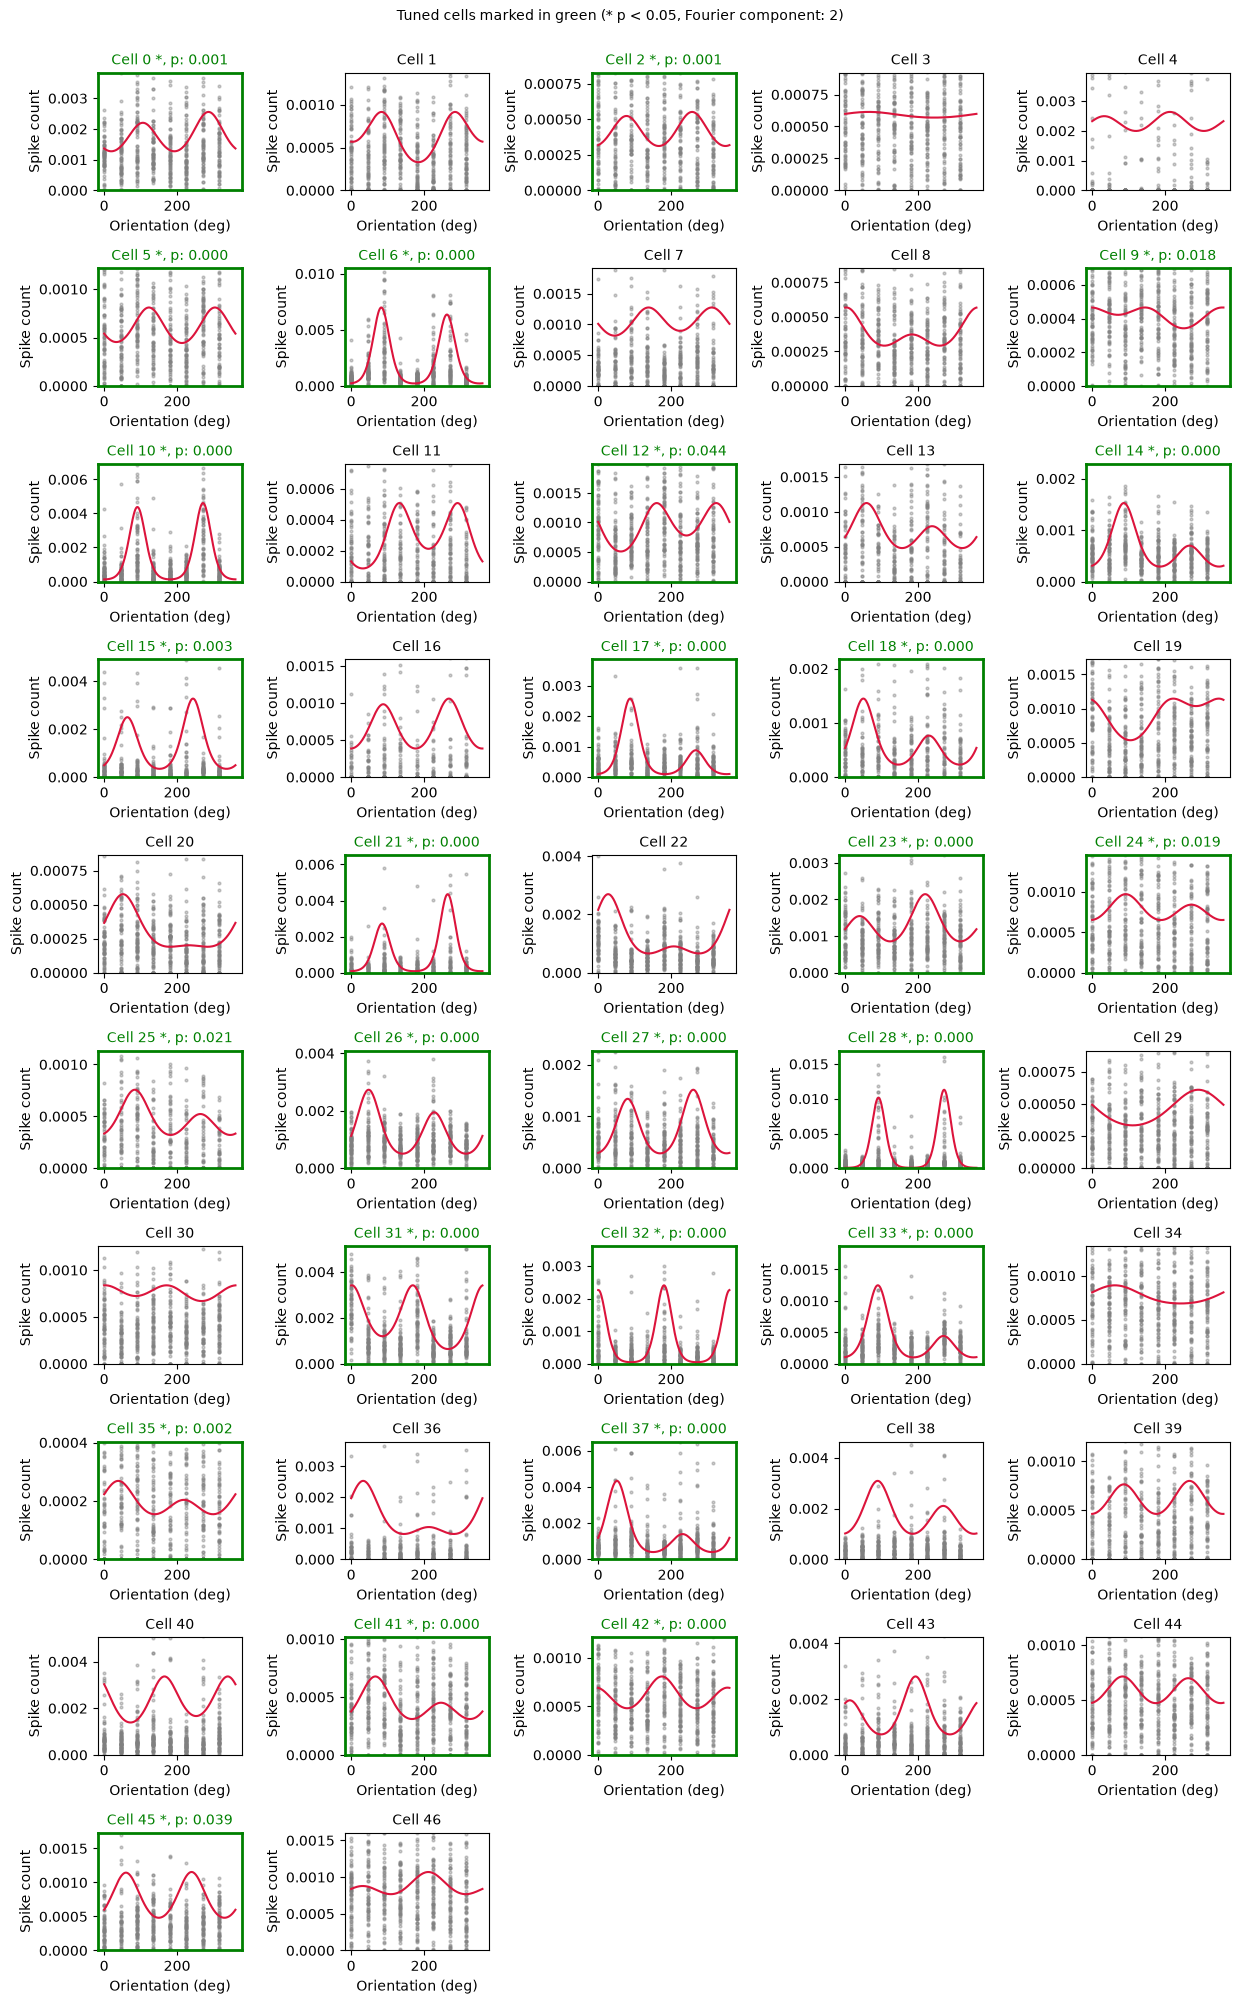

In [164]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=5,
    alpha=0.05,
    psi=PSI
)
plt.show()

In [165]:
PSI = 1

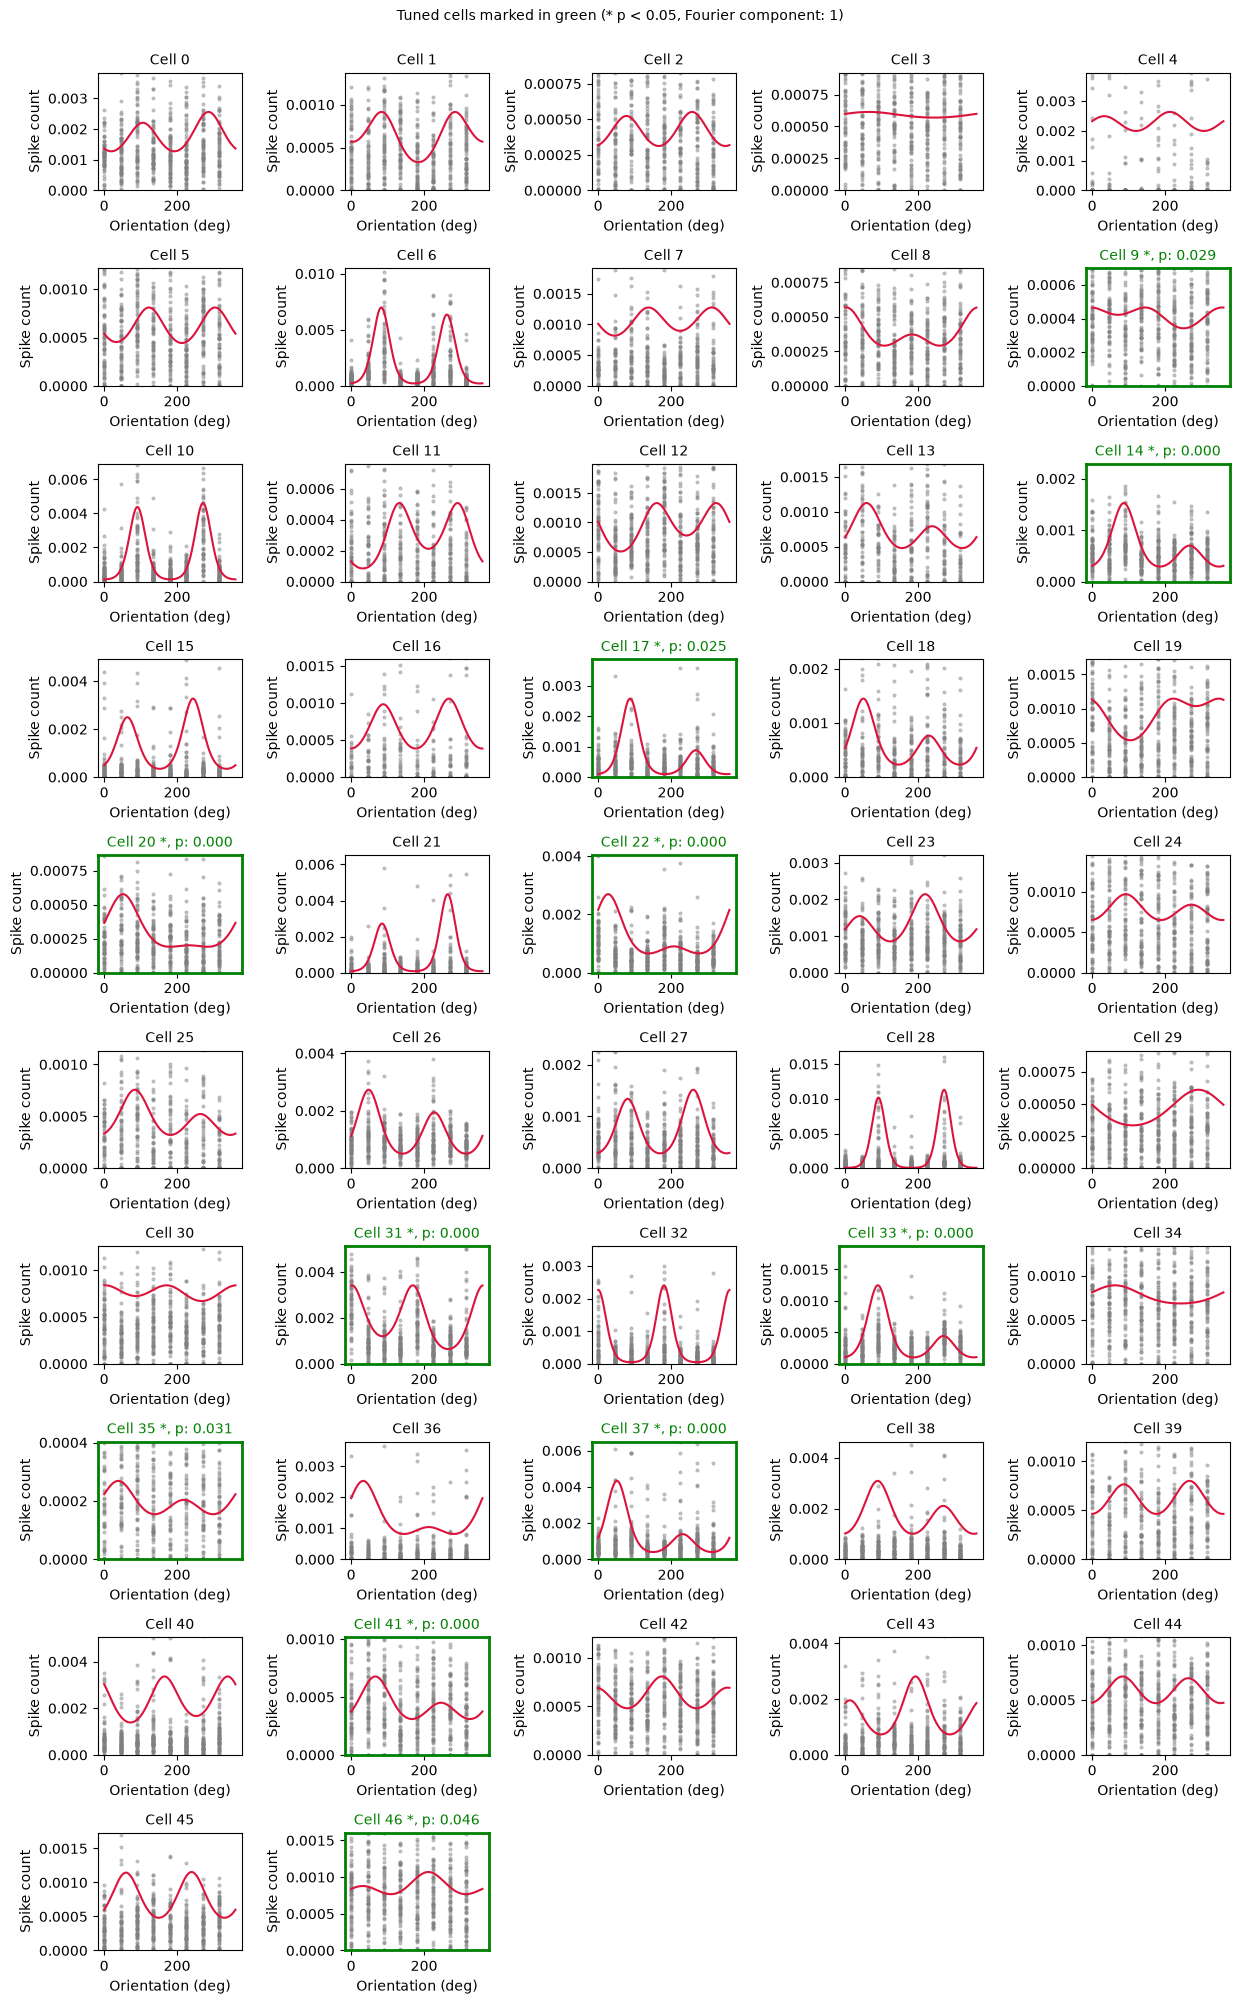

In [167]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test direction selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=5,
    alpha=0.05,
    psi=PSI
)
plt.show()

## 2. Static gratings

In [168]:
sc_per_cell_df = get_spike_count_data(data, session="B", stimulus="static_gratings")

In [169]:
fitted_params = fit_van_mises(
    data,
    sc_per_cell_df,
    session="B",
    stimulus="static_gratings",
    parameter="orientation"
)

In [176]:
PSI = 2

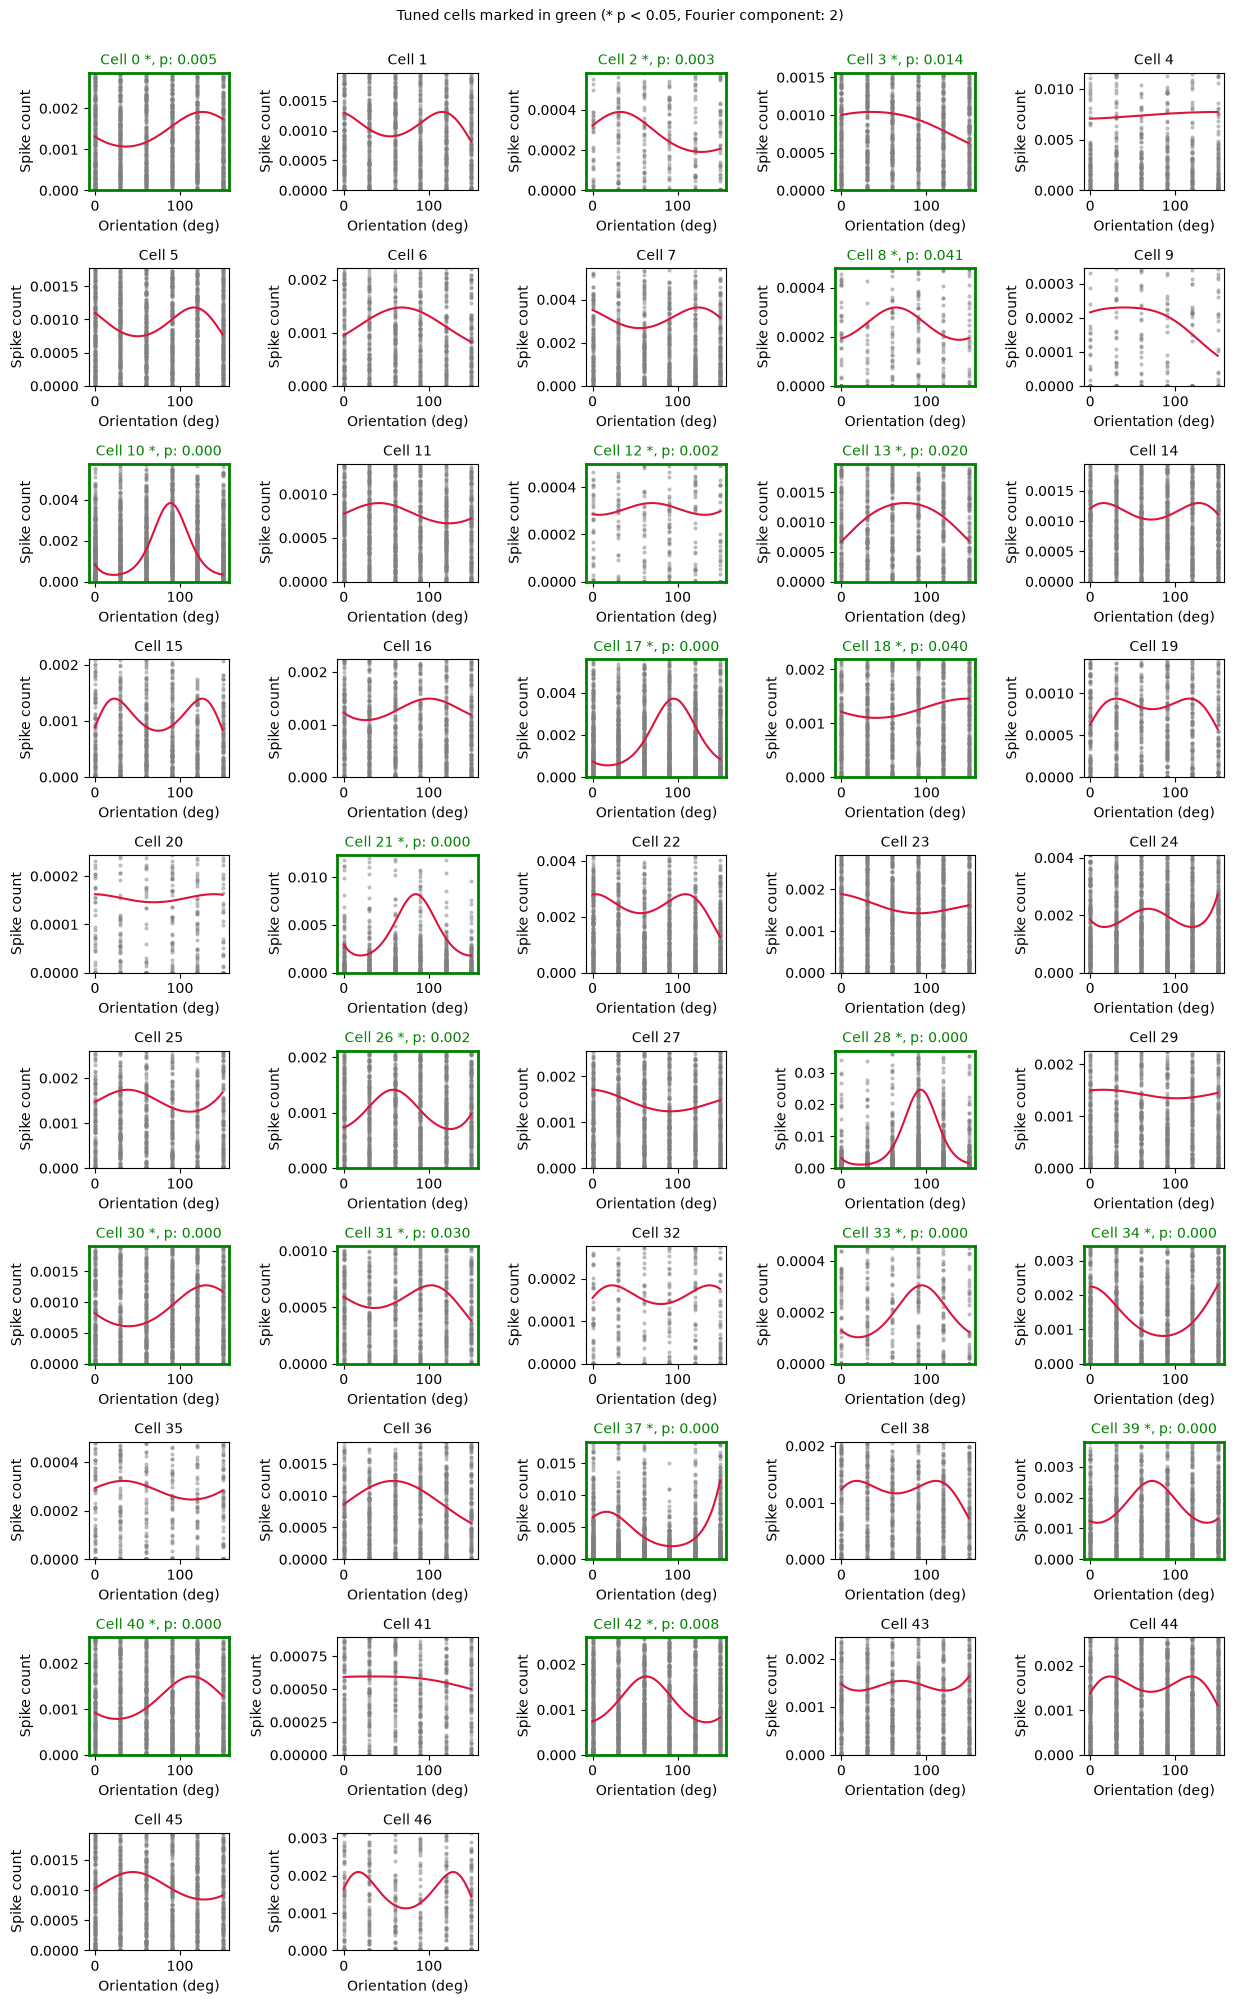

In [177]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=5,
    alpha=0.05,
    psi=PSI
)
plt.show()